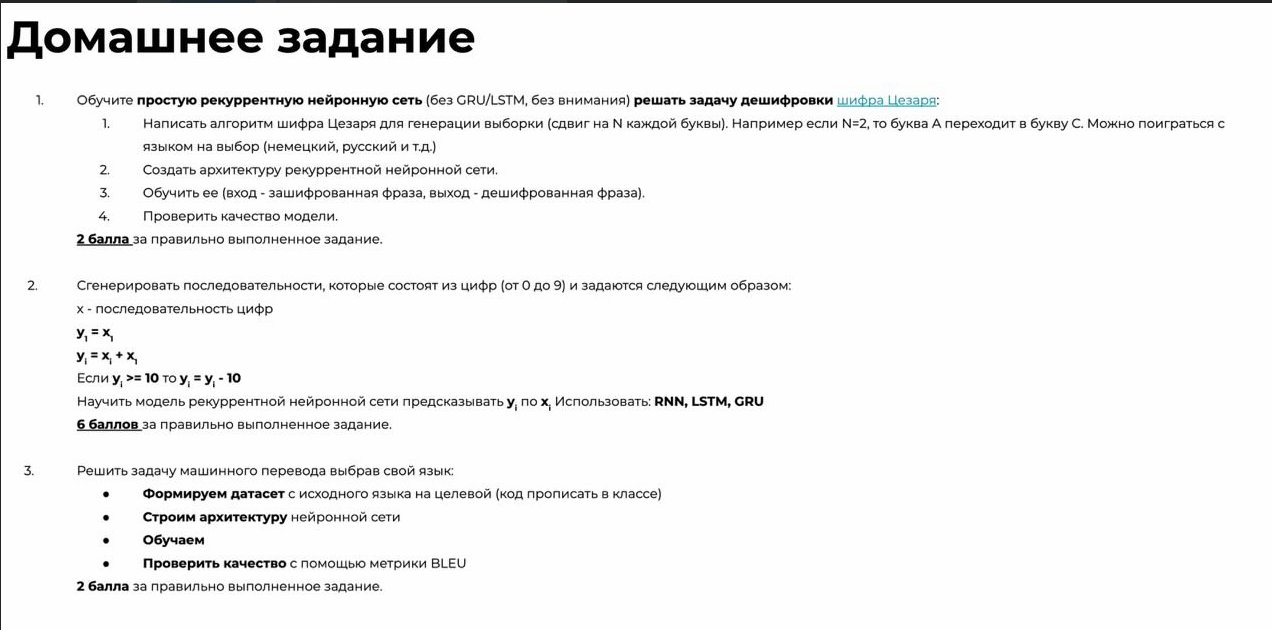

In [1]:
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
def plot_loss(losses, name):
    plt.plot(losses)
    plt.title(name)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid()
    plt.show()

def calc_acc(pred, target):
    pred = pred.argmax(dim=-1)
    
    return (pred == target).float().mean().item()

In [3]:
alphabet = " abcdefghijklmnopqrstuvwxyz"
c2i = {c: i for i, c in enumerate(alphabet)}
i2c = {i: c for i, c in enumerate(alphabet)}

def shift_text(text, k=3):
    res = ""

    for ch in text:
        idx = c2i[ch]
        res += i2c[(idx + k) % len(alphabet)]

    return res

def make_data(n=2000, L=10):
    X, Y = [], []
    
    for _ in range(n):
        w = "".join(random.choice(alphabet) for _ in range(L)) 
        enc = shift_text(w, 3)
        X.append([c2i[c] for c in enc])
        Y.append([c2i[c] for c in w])

    return torch.tensor(X), torch.tensor(Y)

X, Y = make_data()
X, Y = X.to(device), Y.to(device)

cut = int(0.8 * len(X))
Xtr, Xte = X[:cut], X[cut:]
Ytr, Yte = Y[:cut], Y[cut:]

In [4]:
class RNN1(nn.Module):
    def __init__(self, vs, h=64):
        super().__init__()
        self.emb = nn.Embedding(vs, h)
        self.rnn = nn.RNN(h, h, batch_first=True)
        self.lin = nn.Linear(h, vs)

    def forward(self, x):
        x = self.emb(x)
        out, _ = self.rnn(x)
        
        return self.lin(out)

model1 = RNN1(len(alphabet)).to(device)
opt1 = torch.optim.Adam(model1.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()

ep 0: loss=3.3160, acc=0.093
ep 20: loss=0.1062, acc=1.000
ep 40: loss=0.0107, acc=1.000
ep 60: loss=0.0056, acc=1.000
ep 80: loss=0.0043, acc=1.000
ep 100: loss=0.0035, acc=1.000


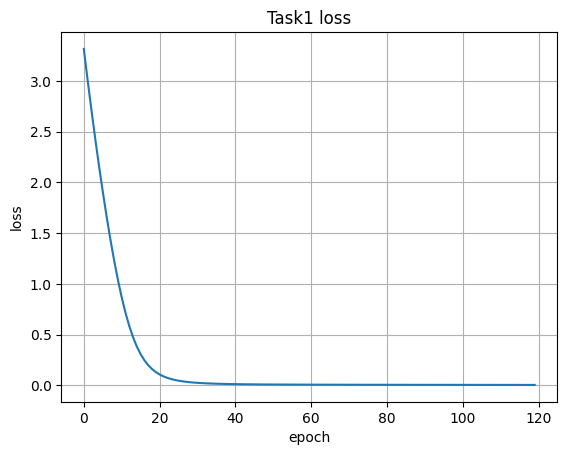

In [5]:
losses1 = []

for ep in range(120):
    model1.train()
    opt1.zero_grad()

    out = model1(Xtr)
    loss = loss_fn(out.view(-1, len(alphabet)), Ytr.view(-1))
    loss.backward()
    opt1.step()

    losses1.append(loss.item())

    if ep % 20 == 0:
        acc = calc_acc(out, Ytr)
        
        print(f"ep {ep}: loss={loss.item():.4f}, acc={acc:.3f}")

plot_loss(losses1, "Task1 loss")

In [6]:
model1.eval()

with torch.no_grad():
    out = model1(Xte)
    acc = calc_acc(out, Yte)

    print("test acc:", acc)

test = "hello world"

enc = shift_text(test, 3)
xt = torch.tensor([[c2i[c] for c in enc]]).to(device)

pred = model1(xt).argmax(2).squeeze().tolist()
dec = "".join(i2c[i] for i in pred)

print("orig:", test)
print("enc :", enc)
print("dec :", dec)

test acc: 1.0
orig: hello world
enc : khoorczruog
dec : hello world


In [7]:
test = "My name Roman".lower()

enc = shift_text(test, 3)
xt = torch.tensor([[c2i[c] for c in enc]]).to(device)

pred = model1(xt).argmax(2).squeeze().tolist()
dec = "".join(i2c[i] for i in pred)

print("orig:", test)
print("enc :", enc)
print("dec :", dec)

orig: my name roman
enc : pacqdphcurpdq
dec : my name roman


TASK 2

In [8]:
def gen_seq(n=2500, L=12):
    X, Y = [], []

    for _ in range(n):
        x = [random.randint(0, 9) for _ in range(L)]
        y = []

        for i in range(L):
            if i == 0:
                y.append(x[i])
            else:
                s = x[i] + x[i-1]
                y.append(s % 10)

        X.append(x)
        Y.append(y)
        
    return torch.tensor(X), torch.tensor(Y)

X, Y = gen_seq()
X, Y = X.to(device), Y.to(device)
cut = int(0.8 * len(X))
Xtr, Xte = X[:cut], X[cut:]
Ytr, Yte = Y[:cut], Y[cut:]

In [9]:
class RNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(10, 64)
        self.rnn = nn.RNN(64, 64, batch_first=True)
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.emb(x)
        out, _ = self.rnn(x)

        return self.fc(out)

class LSTM2(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(10, 64)
        self.lstm = nn.LSTM(64, 64, batch_first=True)
        self.fc = nn.Linear(64, 10)
    def forward(self, x):
        x = self.emb(x)
        out, _ = self.lstm(x)

        return self.fc(out)

class GRU2(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(10, 64)
        self.gru = nn.GRU(64, 64, batch_first=True)
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.emb(x)
        out, _ = self.gru(x)
        
        return self.fc(out)

In [10]:
model_rnn = RNN2().to(device)
model_lstm = LSTM2().to(device)
model_gru = GRU2().to(device)

opt_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.005)
opt_lstm = torch.optim.Adam(model_lstm.parameters(), lr=0.005)
opt_gru = torch.optim.Adam(model_gru.parameters(), lr=0.005)

RNN ep 0: loss=2.3432345390319824
RNN ep 20: loss=1.4094740152359009
RNN ep 40: loss=0.32192522287368774
RNN ep 60: loss=0.07852905243635178
RNN ep 80: loss=0.03599204123020172
RNN ep 100: loss=0.02299330197274685


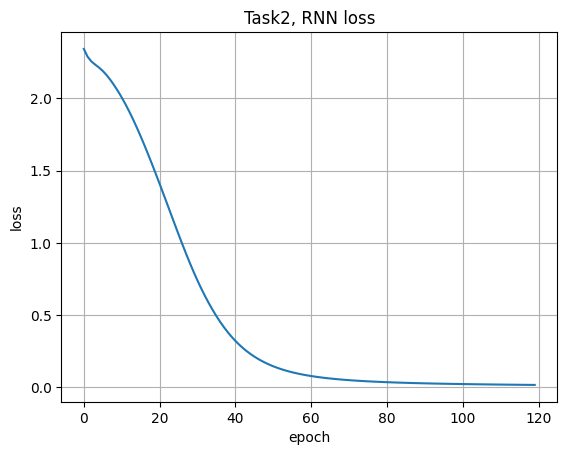

In [11]:
losses_rnn = []

for ep in range(120):
    opt_rnn.zero_grad()
    out = model_rnn(Xtr)
    loss = loss_fn(out.view(-1, 10), Ytr.view(-1))
    loss.backward()
    opt_rnn.step()
    losses_rnn.append(loss.item())

    if ep % 20 == 0:
        print(f"RNN ep {ep}: loss={loss.item()}")

plot_loss(losses_rnn, "Task2, RNN loss")

LSTM ep 0: loss=2.3120601177215576
LSTM ep 20: loss=1.5119928121566772
LSTM ep 40: loss=0.35012105107307434
LSTM ep 60: loss=0.06047895923256874
LSTM ep 80: loss=0.023850809782743454
LSTM ep 100: loss=0.014627385884523392


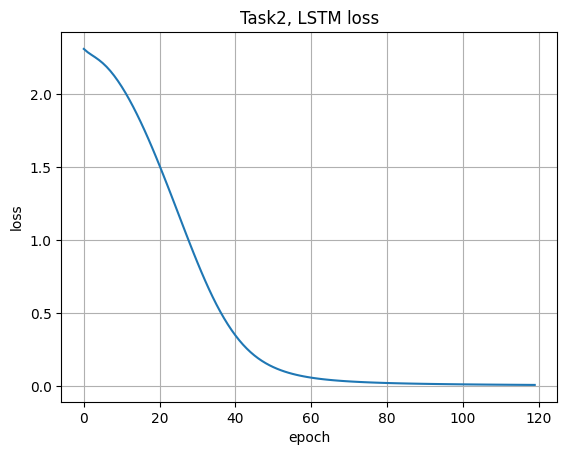

In [12]:
losses_lstm = []
for ep in range(120):
    opt_lstm.zero_grad()
    out = model_lstm(Xtr)
    loss = loss_fn(out.view(-1, 10), Ytr.view(-1))
    loss.backward()
    opt_lstm.step()
    losses_lstm.append(loss.item())

    if ep % 20 == 0:
        print(f"LSTM ep {ep}: loss={loss.item()}")

plot_loss(losses_lstm, "Task2, LSTM loss")

GRU ep 0: loss=2.3105626106262207
GRU ep 20: loss=1.1968989372253418
GRU ep 40: loss=0.19941939413547516
GRU ep 60: loss=0.04503012076020241
GRU ep 80: loss=0.020930392667651176
GRU ep 100: loss=0.013455718755722046


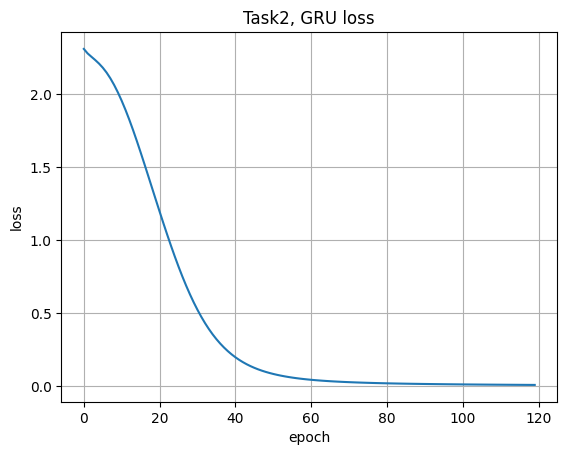

In [13]:
losses_gru = []

for ep in range(120):
    opt_gru.zero_grad()
    out = model_gru(Xtr)
    loss = loss_fn(out.view(-1, 10), Ytr.view(-1))
    loss.backward()
    opt_gru.step()
    losses_gru.append(loss.item())

    if ep % 20 == 0:
        print(f"GRU ep {ep}: loss={loss.item()}")
        
plot_loss(losses_gru, "Task2, GRU loss")

In [14]:
model_rnn.eval()
model_lstm.eval()
model_gru.eval()

with torch.no_grad():
    out_rnn = model_rnn(Xte)
    out_lstm = model_lstm(Xte)
    out_gru = model_gru(Xte)
    acc_rnn = calc_acc(out_rnn, Yte)
    acc_lstm = calc_acc(out_lstm, Yte)
    acc_gru = calc_acc(out_gru, Yte)

print("test acc RNN:", acc_rnn)
print("test acc LSTM:", acc_lstm)
print("test acc GRU:", acc_gru)

test acc RNN: 1.0
test acc LSTM: 1.0
test acc GRU: 1.0


In [15]:
x = [random.randint(0, 9) for _ in range(10)]
xt = torch.tensor([x]).to(device)

with torch.no_grad():
    pred_rnn = model_rnn(xt).argmax(2).squeeze().tolist()
    pred_lstm = model_lstm(xt).argmax(2).squeeze().tolist()
    pred_gru = model_gru(xt).argmax(2).squeeze().tolist()

true = []
for i in range(len(x)):
    if i == 0:
        true.append(x[i])
    else:
        true.append((x[i] + x[i-1]) % 10)

print("x:", x)
print("true:", true)
print("RNN:", pred_rnn)
print("LSTM:", pred_lstm)
print("GRU:", pred_gru)

x: [9, 8, 8, 9, 1, 5, 7, 0, 6, 4]
true: [9, 7, 6, 7, 0, 6, 2, 7, 6, 0]
RNN: [9, 7, 6, 7, 0, 6, 2, 7, 6, 0]
LSTM: [9, 7, 6, 7, 0, 6, 2, 7, 6, 0]
GRU: [9, 7, 6, 7, 0, 6, 2, 7, 6, 0]


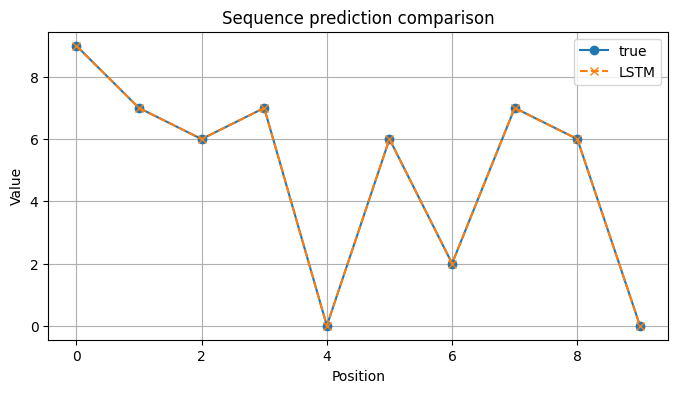

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(true, marker='o', label='true')
plt.plot(pred_lstm, marker='x', linestyle='--', label='LSTM')
plt.title("Sequence prediction comparison")
plt.xlabel("Position")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

TASK 3

In [17]:
pairs = [
    ("hola", "привет"),
    ("buenos dias", "доброе утро"),
    ("buenas tardes", "добрый день"),
    ("buenas noches", "спокойной ночи"),
    ("adios", "пока"),
    ("hasta luego", "до встречи"),
    ("hasta pronto", "до скорого"),
    ("hasta manana", "до завтра"),
    ("nos vemos", "увидимся"),
    ("por favor", "пожалуйста"),
    ("gracias", "спасибо"),
    ("muchas gracias", "большое спасибо"),
    ("de nada", "не за что"),
    ("lo siento", "извините"),
    ("perdon", "прости"),
    ("como estas", "как дела"),
    ("que tal", "как дела"),
    ("como te llamas", "как тебя зовут"),
    ("de donde eres", "откуда ты"),
    ("que es esto", "что это"),
    ("donde estas", "где ты"),
    ("que hora es", "который час"),
    ("hablas ruso", "ты говоришь по русски"),
    ("si", "да"),
    ("no", "нет"),
    ("muy bien", "очень хорошо"),
    ("estoy bien", "я в порядке"),
    ("mas o menos", "так себе"),
    ("no entiendo", "я не понимаю"),
    ("yo se", "я знаю"),
    ("no se", "я не знаю"),
    ("te quiero", "я тебя люблю"),
    ("te amo", "я люблю тебя"),
    ("me gusta", "мне нравится"),
    ("no me gusta", "мне не нравится"),
    ("tengo hambre", "я хочу есть"),
    ("tengo sed", "я хочу пить"),
    ("tengo frio", "мне холодно"),
    ("tengo calor", "мне жарко"),
    ("estoy cansado", "я устал"),
    ("estoy feliz", "я счастлив"),
    ("donde esta el bano", "где туалет"),
    ("vamos a casa", "пойдем домой"),
    ("buen provecho", "приятного аппетита"),
    ("bienvenido", "добро пожаловать")
]

In [18]:
class Vocab:
    def __init__(self):
        self.w2i = {"<pad>":0, "<s>":1, "</s>":2}
        self.i2w = {0:"<pad>", 1:"<s>", 2:"</s>"}
        self.idx = 3

    def add(self, sent):
        for w in sent.split():
            
            if w not in self.w2i:
                self.w2i[w] = self.idx
                self.i2w[self.idx] = w
                self.idx += 1

In [19]:
src_v, trg_v = Vocab(), Vocab()

for s, t in pairs:
    src_v.add(s)
    trg_v.add(t)

In [20]:
def encode(sent, vocab, max_len=6):
    ids = [vocab.w2i["<s>"]]
    ids += [vocab.w2i[w] for w in sent.split()]
    ids += [vocab.w2i["</s>"]]

    while len(ids) < max_len:
        ids.append(0)
        
    return ids[:max_len]

src = torch.tensor([encode(s, src_v) for s, _ in pairs]).to(device)
trg = torch.tensor([encode(t, trg_v) for _, t in pairs]).to(device)

In [21]:
class Enc(nn.Module):
    def __init__(self):
        super().__init__()
        self.e = nn.Embedding(src_v.idx, 64)
        self.r = nn.GRU(64, 128, batch_first=True)

    def forward(self, x):
        _, h = self.r(self.e(x)) 
        
        return h

class Dec(nn.Module):
    def __init__(self):
        super().__init__()
        self.e = nn.Embedding(trg_v.idx, 64)
        self.r = nn.GRU(64, 128, batch_first=True)
        self.f = nn.Linear(128, trg_v.idx)

    def forward(self, x, h):
        x = x.unsqueeze(1)
        o, h = self.r(self.e(x), h)

        return self.f(o.squeeze(1)), h

In [22]:
enc = Enc().to(device)
dec = Dec().to(device)

opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=0.001)
loss_fn_t = nn.CrossEntropyLoss(ignore_index=0)

ep 0: loss=4.241067409515381
ep 40: loss=1.7740293741226196
ep 80: loss=1.2933189868927002
ep 120: loss=0.408914715051651
ep 160: loss=0.10369837284088135


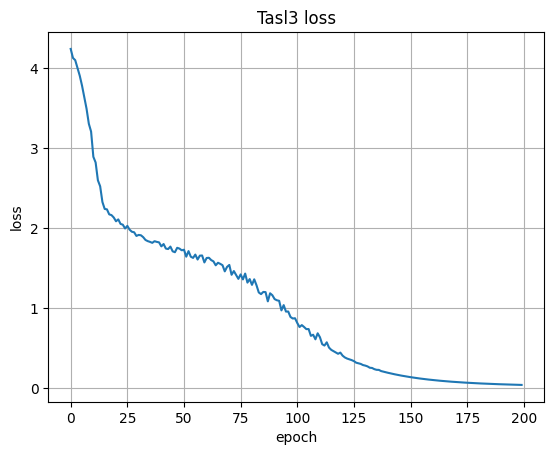

In [23]:
losses3 = []
enc.train()
dec.train()

for ep in range(200):
    opt.zero_grad()
    
    h = enc(src) 
    
    inp = trg[:, 0]
    total_loss = 0
    valid_steps = 0
    
    for t in range(1, trg.shape[1]):
        out, h = dec(inp, h)
        
        if (trg[:, t] != 0).any():
            step_loss = loss_fn_t(out, trg[:, t])
            total_loss += step_loss
            valid_steps += 1
            
        if random.random() < 0.5:
            inp = trg[:, t]
            
        else:
            inp = out.argmax(1)
            
    if valid_steps > 0:
        total_loss = total_loss / valid_steps
        
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(enc.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(dec.parameters(), max_norm=1.0)
    opt.step()
    
    losses3.append(total_loss.item())
    
    if ep % 40 == 0:
        print(f"ep {ep}: loss={total_loss.item()}")

plot_loss(losses3, "Tasl3 loss")

In [24]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def translate(s):
    enc.eval(); dec.eval()

    with torch.no_grad():
        x = torch.tensor([encode(s, src_v)]).to(device)
        h = enc(x)

        cur = torch.tensor([trg_v.w2i["<s>"]]).to(device)
        res = []

        for _ in range(6):
            out, h = dec(cur, h)
            nxt = out.argmax(1).item()

            if nxt == trg_v.w2i["</s>"]:
                break

            res.append(trg_v.i2w[nxt])
            cur = torch.tensor([nxt]).to(device)

    return " ".join(res)

smoother = SmoothingFunction().method1 
total_bleu = 0

for s, t in pairs:
    pred_str = translate(s)
    
    reference = [t.split()]
    candidate = pred_str.split()
    score = sentence_bleu(reference, candidate, smoothing_function=smoother)
    total_bleu += score
    
    if pred_str != t:
        print(f"faild translate: {s} to {t}, get {pred_str}, BLEU: {score}")
    else:
        print(f"success translate: {s} to {pred_str}, BLEU: {score}")

print(f"Average BLEU: {total_bleu / len(pairs)}")

success translate: hola to привет, BLEU: 0.1778279410038923
success translate: buenos dias to доброе утро, BLEU: 0.316227766016838
success translate: buenas tardes to добрый день, BLEU: 0.316227766016838
success translate: buenas noches to спокойной ночи, BLEU: 0.316227766016838
success translate: adios to пока, BLEU: 0.1778279410038923
success translate: hasta luego to до встречи, BLEU: 0.316227766016838
success translate: hasta pronto to до скорого, BLEU: 0.316227766016838
success translate: hasta manana to до завтра, BLEU: 0.316227766016838
success translate: nos vemos to увидимся, BLEU: 0.1778279410038923
success translate: por favor to пожалуйста, BLEU: 0.1778279410038923
success translate: gracias to спасибо, BLEU: 0.1778279410038923
success translate: muchas gracias to большое спасибо, BLEU: 0.316227766016838
success translate: de nada to не за что, BLEU: 0.5623413251903491
success translate: lo siento to извините, BLEU: 0.1778279410038923
success translate: perdon to прости, BL